In [ ]:
!pip install fuzzywuzzy


In [ ]:
pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 21.6 MB/s eta 0:00:00


In [ ]:
pip install countrynames

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.9/474.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import pickle

# Load the replications CSV
replications = pd.read_csv("/content/csv2 - Sheet1.csv")

# Also load main_df from Excel
main_df = pd.read_excel("/content/wbg_Updated_7.xlsx")

# Step 0: Define alias and normalization logic
manual_aliases = {
    "islamic republic of pakistan": "Pakistan",
    "viet nam": "Vietnam",
    "lao pdr": "Laos",
    "russian federation": "Russia",
    "united republic of tanzania": "Tanzania",
    "republic of moldova": "Moldova",
    "state of palestine": None,
    "republic of north macedonia": "North Macedonia",
    "republic of cape verde": "Cabo Verde",
    "central african republic": "Central African Republic",
    "sierra leone": "Sierra Leone",
    "east asia and pacific": None,
    "south asia": None,
    "europe and central asia": None,
    "middle east and north africa region": None,
    "africa region": None,
    "yugoslavia": None,
    "hogwarts": None,
    "narnia": None,
    "south east europe": None
}

regions_to_exclude = [
    "East Asia And Pacific", "South Asia", "Europe And Central Asia",
    "Middle East And North Africa Region", "Africa Region", "Yugoslavia",
    "Hogwarts", "Narnia", "State Of Palestine", "South East Europe"
]

def normalize_country(name):
    if pd.isna(name):
        return None
    name_cleaned = str(name).strip().lower().replace('\u00a0', ' ')
    return manual_aliases.get(name_cleaned, name.title())

# Step 1: Normalize country names in main_df
main_df['Country'] = main_df['Country'].apply(normalize_country)

# Step 2: Map Project ID to normalized Country
main_df_cleaned = main_df.drop_duplicates(subset='Project ID', keep='first')
project_id_to_country = main_df_cleaned.set_index('Project ID')['Country'].to_dict()

# Step 3: Convert replication list of dicts to DataFrame
replications = pd.DataFrame(replications)

# Step 4: Add country info
replications['country_1'] = replications['document_id_1'].map(project_id_to_country)
replications['country_2'] = replications['document_id_2'].map(project_id_to_country)

# Step 5: Drop replications with missing or region-based countries
replications = replications.dropna(subset=['country_1', 'country_2'])

# Step 6: Sort and deduplicate country and project pairs
replications['country_pair'] = replications.apply(
    lambda row: tuple(sorted([row['country_1'], row['country_2']])), axis=1
)
replications['project_pair'] = replications.apply(
    lambda row: tuple(sorted([row['document_id_1'], row['document_id_2']])), axis=1
)
replications = replications.drop_duplicates(subset=['project_pair'])

# Step 7: Drop helper columns
replications.drop(columns=['country_pair', 'project_pair'], inplace=True)

# ✅ Output previews
print("Cleaned replications (no regions, no A-B/B-A duplicates):")
print(replications[['document_id_1', 'country_1', 'document_id_2', 'country_2', 'z_score']].head())




# Show successful mappings
print("✅ Successfully mapped replications with countries and years:")
print(replications[['document_id_1', 'country_1', 'document_id_2', 'country_2', 'z_score']].dropna().head())


Cleaned replications (no regions, no A-B/B-A duplicates):
  document_id_1   country_1 document_id_2   country_2   z_score
0       P005736     Tunisia       P065129      Guinea  1.684267
1       P009125  Uzbekistan       P071025   Argentina  1.688147
2       P035813  Azerbaijan       P046043  Uzbekistan  1.959888
3       P045264       China       P122123      Zambia  1.615939
4       P046564       China       P081255       China  1.533268
✅ Successfully mapped replications with countries and years:
  document_id_1   country_1 document_id_2   country_2   z_score
0       P005736     Tunisia       P065129      Guinea  1.684267
1       P009125  Uzbekistan       P071025   Argentina  1.688147
2       P035813  Azerbaijan       P046043  Uzbekistan  1.959888
3       P045264       China       P122123      Zambia  1.615939
4       P046564       China       P081255       China  1.533268


In [ ]:
# Step 2: Remove self-replications (same country)
replications_no_self = replications[replications['country_1'] != replications['country_2']].copy()

# Step 3: Create sorted country pairs (A–B same as B–A)
replications_no_self['country_pair'] = replications_no_self.apply(
    lambda row: tuple(sorted([row['country_1'], row['country_2']])), axis=1
)

# Step 4: Drop duplicate country pairs
replications_unique = replications_no_self.drop_duplicates(subset=['country_pair'])

# Optional: Reset index
replications_unique.reset_index(drop=True, inplace=True)

# ✅ View cleaned unique cross-country replication set
print("✅ Unique cross-country replications (no self-replications, no duplicates):")
print(replications_unique[['document_id_1', 'country_1',
                           'document_id_2', 'country_2', 'z_score']].head())


✅ Unique cross-country replications (no self-replications, no duplicates):
  document_id_1   country_1 document_id_2           country_2   z_score
0       P005736     Tunisia       P065129              Guinea  1.684267
1       P009125  Uzbekistan       P071025           Argentina  1.688147
2       P035813  Azerbaijan       P046043          Uzbekistan  1.959888
3       P045264       China       P122123              Zambia  1.615939
4       P049581      Jordan       P107050  Yemen, Republic Of  1.650184


In [ ]:
# 1. Exclude rows where either country is missing or a known region
replications_filtered = replications[
    replications['country_1'].notna() &
    replications['country_2'].notna() &
    ~replications['country_1'].isin(regions_to_exclude) &
    ~replications['country_2'].isin(regions_to_exclude)
].copy()

# 2. Remove self-replications
replications_filtered_no_self = replications_filtered[
    replications_filtered['country_1'] != replications_filtered['country_2']
].copy()

# 3. Sort and create country_pair to avoid A–B / B–A duplication
replications_filtered_no_self['country_pair'] = replications_filtered_no_self.apply(
    lambda row: tuple(sorted([row['country_1'], row['country_2']])), axis=1
)

# 4. Remove duplicate pairs (A–B and B–A with same projects)
replications_filtered_no_self = replications_filtered_no_self.drop_duplicates(
    subset=['country_pair', 'document_id_1', 'document_id_2']
).copy()

# 5. Group by normalized pairs and count occurrences
pair_counts_filtered = replications_filtered_no_self.groupby('country_pair').size().reset_index(name='count')

# 6. Split tuple into two columns
pair_counts_filtered[['country_1', 'country_2']] = pd.DataFrame(
    pair_counts_filtered['country_pair'].tolist(), index=pair_counts_filtered.index
)

# 7. Drop the tuple and sort by count
pair_counts_filtered = pair_counts_filtered.drop(columns=['country_pair']).sort_values(by='count', ascending=False)

# ✅ Preview top country pairs
print("📌 Top replicated country pairs:")
print(pair_counts_filtered.head())


📌 Top replicated country pairs:
     count   country_1                  country_2
64       7  Bangladesh                      India
211      6       China                      India
213      5       China  Iran, Islamic Republic Of
319      4      Guinea                    Senegal
152      4      Brazil                       Peru


In [ ]:
country_coords = {
    'Guatemala': ('Guatemala City', (14.6349, -90.5069)),
    'Palestine': ('Ramallah', (31.8997, 35.2996)),
    'Democratic Republic of Congo': ('Kinshasa', (-4.4419, 15.2663)),
    'Zambia': ('Lusaka', (-15.3875, 28.3228)),
    'Ecuador': ('Quito', (-0.1807, -78.4678)),
    'Senegal': ('Dakar', (14.6928, -17.4467)),
    'Dominican Republic': ('Santo Domingo', (18.4861, -69.9312)),
    'Albania': ('Tirana', (41.3275, 19.8189)),
    'Bosnia and Herzegovina': ('Sarajevo', (43.8486, 18.3564)),
    'Algeria': ('Algiers', (36.7377, 3.0864)),
    'Benin': ('Porto-Novo', (6.4969, 2.6289)),
    'Chile': ('Santiago', (-33.4489, -70.6693)),
    'Dominica': ('Roseau', (15.3015, -61.3881)),
    'Switzerland': ('Bern', (46.9481, 7.4474)),
    'Sweden': ('Stockholm', (59.3293, 18.0686)),
    'Montenegro': ('Podgorica', (42.4411, 19.2636)),
    'Solomon Islands': ('Honiara', (-9.7441, 160.0048)),
    'Ghana': ('Accra', (5.6037, -0.1870)),
    'Denmark': ('Copenhagen', (55.6761, 12.5683)),
    'Nicaragua': ('Managua', (12.1364, -86.2514)),
    'Zimbabwe': ('Harare', (-17.8292, 31.0522)),
    'Grenada': ('St. George\'s', (12.0560, -61.7485)),
    'Chad': ('N\'Djamena', (12.1348, 15.0557)),
    'Egypt': ('Cairo', (30.0444, 31.2357)),
    'Kyrgyzstan': ('Bishkek', (42.8746, 74.6123)),
    'Italy': ('Rome', (41.9028, 12.4964)),
    'Colombia': ('Bogotá', (4.7110, -74.0721)),
    'Romania': ('Bucharest', (44.4268, 26.1025)),
    'Thailand': ('Bangkok', (13.7563, 100.5018)),
    'Liberia': ('Monrovia', (6.4281, -9.4295)),
    'Eswatini': ('Mbabane', (-26.3180, 31.1416)),
    'Jamaica': ('Kingston', (17.9714, -76.7936)),
    'Sierra Leone': ('Freetown', (8.4657, -13.2317)),
    'Papua New Guinea': ('Port Moresby', (-9.4438, 147.1800)),
    'Saint Lucia': ('Castries', (13.9897, -61.9783)),
    'Antigua and Barbuda': ('Saint John\'s', (17.1172, -61.8468)),
    'Belgium': ('Brussels', (50.8503, 4.3517)),
    'Barbados': ('Bridgetown', (13.1, -59.6167)),
    'Botswana': ('Gaborone', (-24.6282, 25.9231)),
    'Georgia': ('Tbilisi', (41.7151, 44.8271)),
    'Singapore': ('Singapore', (1.3521, 103.8198)),
    'Belize': ('Belmopan', (17.1899, -88.4977)),
    'Paraguay': ('Asunción', (-25.2637, -57.5759)),
    'Azerbaijan': ('Baku', (40.4093, 49.8671)),
    'Panama': ('Panama City', (8.9833, -79.5167)),
    'Mauritius': ('Port Louis', (-20.1609, 57.5012)),
    'Rwanda': ('Kigali', (-1.9441, 30.0619)),
    'Bulgaria': ('Sofia', (42.6975, 23.3242)),
    'Mongolia': ('Ulaanbaatar', (47.8864, 106.9057)),
    'Bhutan': ('Thimphu', (27.4710, 89.6333)),
    'Macedonia': ('Skopje', (41.9981, 21.4254)),
    'North Macedonia': ('Skopje', (41.9981, 21.4254)),
    'Jordan': ('Amman', (31.9539, 35.9106)),
    'Suriname': ('Paramaribo', (5.8667, -55.1667)),
    'Madagascar': ('Antananarivo', (-18.8792, 47.5079)),
    'Latvia': ('Riga', (56.9460, 24.1059)),
    'Portugal': ('Lisbon', (38.7169, -9.1395)),
    'Samoa': ('Apia', (-13.8357, -171.7650)),
    'Iran': ('Tehran', (35.6892, 51.3890)),
    'Vanuatu': ('Port Vila', (-17.7333, 168.3167)),
    'Austria': ('Vienna', (48.2082, 16.3738)),
    'Kuwait': ('Kuwait City', (29.3759, 47.9774)),
    'Israel': ('Jerusalem', (31.7683, 35.2137)),
    'Tonga': ('Nukuʻalofa', (-21.1394, -175.2048)),
    'Gabon': ('Libreville', (0.4167, 9.4670)),
    'Palau': ('Ngerulmud', (7.5149, 134.6237)),
    'Tuvalu': ('Funafuti', (-7.4951, 179.1940)),
    'Nauru': ('Yaren', (-0.5477, 166.9200)),
    'Eritrea': ('Asmara', (15.3229, 38.9251)),
    'Cuba': ('Havana', (23.1136, -82.3666)),
    'Namibia': ('Windhoek', (-22.5597, 17.0836)),
    'Belarus': ('Minsk', (53.9, 27.5667)),
    'Venezuela': ('Caracas', (10.4918, -66.8792)),
    'Norway': ('Oslo', (59.9139, 10.7522)),
    'Ivory Coast': ('Yamoussoukro', (6.8197, -5.2797)),
    'Uruguay': ('Montevideo', (-34.9011, -56.1645)),
    'Swaziland': ('Mbabane', (-26.3054, 31.1367)),
    'Jamaica': ('Kingston', (17.9970, -76.7936)),
    'Sierra Leone': ('Freetown', (8.4840, -13.2299)),
    'Papua New Guinea': ('Port Moresby', (-9.4438, 147.1803)),
    'Saint Lucia': ('Castries', (14.0101, -60.9875)),
    'Antigua And Barbuda': ("Saint John's", (17.1215, -61.8449)),
    'Belgium': ('Brussels', (50.8503, 4.3517)),
    'Barbados': ('Bridgetown', (13.0975, -59.6167)),
    'Botswana': ('Gaborone', (-24.6282, 25.9231)),
    'Georgia': ('Tbilisi', (41.7151, 44.8271)),
    'Singapore': ('Singapore', (1.3521, 103.8198)),
    'Belize': ('Belmopan', (17.2510, -88.7590)),
    'Paraguay': ('Asunción', (-25.2637, -57.5759)),
    'Kyrgyzstan': ('Bishkek', (42.8746, 74.5698)),
    'Azerbaijan': ('Baku', (40.4093, 49.8671)),
    'Panama': ('Panama City', (8.9824, -79.5199)),
    'Korea': ('Seoul', (37.5665, 126.9780)),  # Assuming South Korea
    'Mauritius': ('Port Louis', (-20.1669, 57.5020)),
    'Rwanda': ('Kigali', (-1.9706, 30.1044)),
    'Bulgaria': ('Sofia', (42.6977, 23.3219)),
    'Mongolia': ('Ulaanbaatar', (47.8864, 106.9057)),
    'Bhutan': ('Thimphu', (27.4728, 89.6390)),
    'Macedonia': ('Skopje', (41.9981, 21.4254)),  # Now North Macedonia
    'North Macedonia': ('Skopje', (41.9981, 21.4254)),
    'Sierra\xa0Leone': ('Freetown', (8.4840, -13.2299)),  # Same as 'Sierra Leone'
    'Jordan': ('Amman', (31.9539, 35.9106)),
    'Suriname': ('Paramaribo', (5.8520, -55.2038)),
    'Madagascar': ('Antananarivo', (-18.8792, 47.5079)),
    'Latvia': ('Riga', (56.9496, 24.1052)),
    'Sudan': ('Khartoum', (15.5007, 32.5599)),
    'Micronesia': ('Palikir', (6.9248, 158.1610)),
    'Portugal': ('Lisbon', (38.7169, -9.1399)),
    'Samoa': ('Apia', (-13.8507, -171.7514)),
    'Iran': ('Tehran', (35.6892, 51.3890)),
    'Central African Republic': ('Bangui', (4.3947, 18.5582)),
    'Vanuatu': ('Port Vila', (-17.7333, 168.3273)),
    'Central\xa0African\xa0Republic': ('Bangui', (4.3947, 18.5582)),  # Same as above
    'Austria': ('Vienna', (48.2082, 16.3738)),
    'Kuwait': ('Kuwait City', (29.3759, 47.9774)),
    'Palestinian Territories': ('Ramallah', (31.9038, 35.2034)),  # De facto administrative center
    'Israel': ('Jerusalem', (31.7683, 35.2137)),
    'Tonga': ('Nukuʻalofa', (-21.1393, -175.2018)),
    'Gabon': ('Libreville', (0.4162, 9.4673)),
    'Palau': ('Ngerulmud', (7.5000, 134.6242)),
    'Tuvalu': ('Funafuti', (-8.5167, 179.2167)),
    'Nauru': ('Yaren', (-0.5477, 166.9209)),  # De facto capital
    'Eritrea': ('Asmara', (15.3229, 38.9251)),
    'Cuba': ('Havana', (23.1136, -82.3666)),
    'Namibia': ('Windhoek', (-22.5597, 17.0832)),
    'Belarus': ('Minsk', (53.9006, 27.5590)),
    'Venezuela': ('Caracas', (10.4806, -66.9036)),
    'Norway': ('Oslo', (59.9139, 10.7522)),
    "Côte D'Ivoire": ('Yamoussoukro', (6.8276, -5.2893)),
    'Uruguay': ('Montevideo', (-34.9011, -56.1645))
}


<ipython-input-8-a76df1ac14c0>:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  replications_with_dist['distance_bin'] = pd.cut(


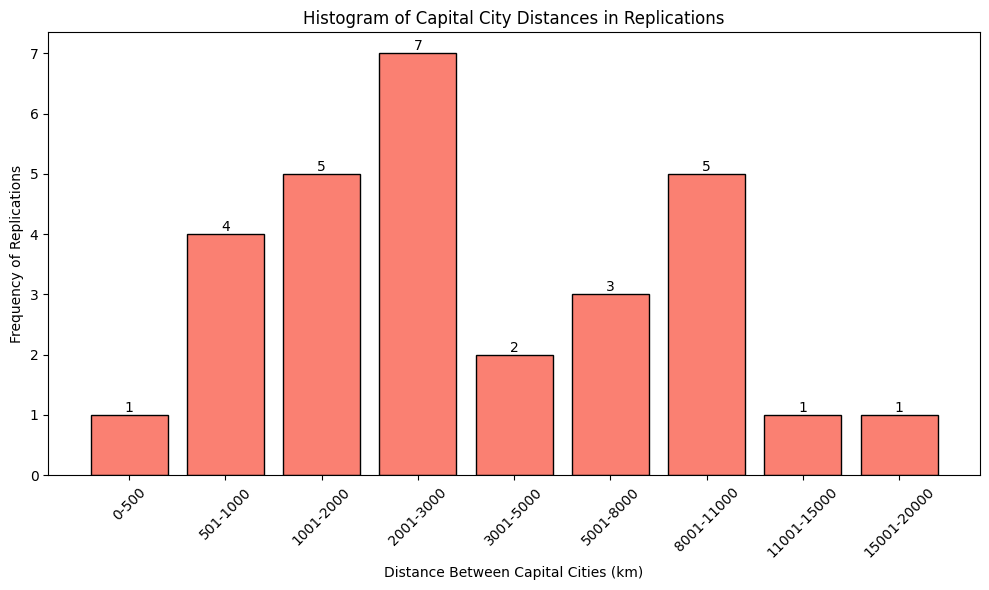

📏 Pearson Correlation Coefficient (Distance vs Z-Score): -0.086
📌 p-value: 6.556e-01


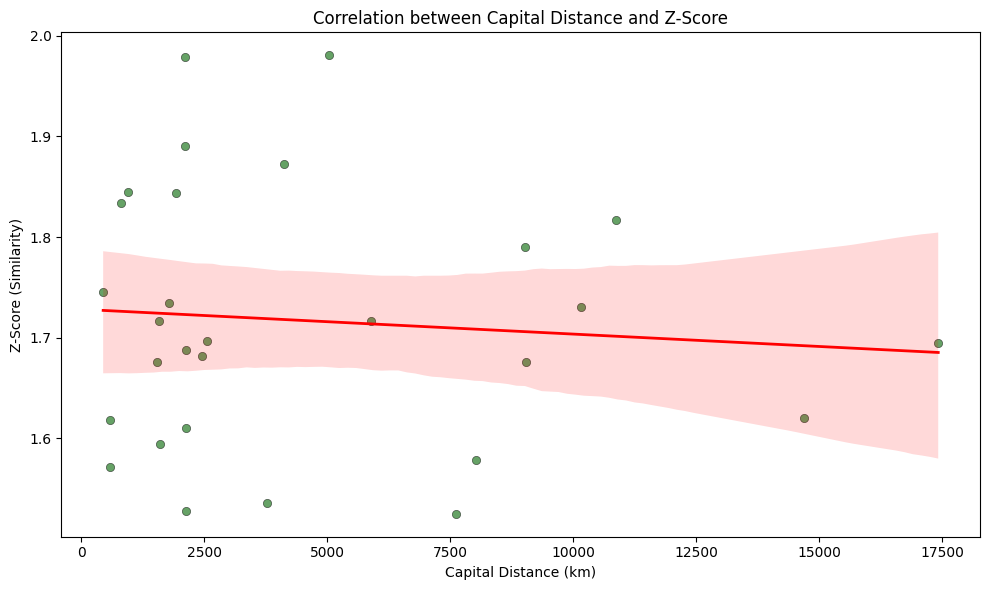

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, asin
from scipy.stats import pearsonr
import seaborn as sns

# Haversine distance function
def haversine(coord1, coord2):
    lat1, lon1 = coord1
    lat2, lon2 = coord2
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371  # Radius of Earth in km
    return c * r

# Get distance between country capital coordinates
def get_distance(row, country_coords):
    c1 = row['country_1']
    c2 = row['country_2']
    if c1 in country_coords and c2 in country_coords:
        coord1 = country_coords[c1][1]
        coord2 = country_coords[c2][1]
        return haversine(coord1, coord2)
    else:
        return None

# Compute distances
replications_filtered_no_self['capital_distance_km'] = replications_filtered_no_self.apply(
    get_distance, axis=1, country_coords=country_coords
)

# Drop rows where the distance is None
replications_with_dist = replications_filtered_no_self.dropna(subset=['capital_distance_km'])

# Define bins and labels for distance
distance_bins = [0, 500, 1000, 2000, 3000, 5000, 8000, 11000, 15000, 20000]
distance_labels = ['0-500', '501-1000', '1001-2000', '2001-3000', '3001-5000',
                   '5001-8000', '8001-11000', '11001-15000', '15001-20000']

replications_with_dist['distance_bin'] = pd.cut(
    replications_with_dist['capital_distance_km'],
    bins=distance_bins,
    labels=distance_labels,
    right=True
)

# Plot histogram of distances
distance_counts = replications_with_dist['distance_bin'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
bars = plt.bar(distance_counts.index, distance_counts.values, color='salmon', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontsize=10)
plt.xlabel('Distance Between Capital Cities (km)')
plt.ylabel('Frequency of Replications')
plt.title('Histogram of Capital City Distances in Replications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Compute Pearson correlation
replications_dist_corr = replications_with_dist.dropna(subset=['capital_distance_km', 'z_score'])
dist_corr, dist_pval = pearsonr(replications_dist_corr['capital_distance_km'], replications_dist_corr['z_score'])
print(f"📏 Pearson Correlation Coefficient (Distance vs Z-Score): {dist_corr:.3f}")
print(f"📌 p-value: {dist_pval:.3e}")

# Scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=replications_dist_corr,
    x='capital_distance_km',
    y='z_score',
    alpha=0.6,
    color='darkgreen',
    edgecolor='black'
)
sns.regplot(
    data=replications_dist_corr,
    x='capital_distance_km',
    y='z_score',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2}
)
plt.title('Correlation between Capital Distance and Z-Score')
plt.xlabel('Capital Distance (km)')
plt.ylabel('Z-Score (Similarity)')
plt.tight_layout()
plt.show()


📏 Pearson Correlation Coefficient (Distance vs Z-Score): -0.082
📌 p-value: 6.789e-01


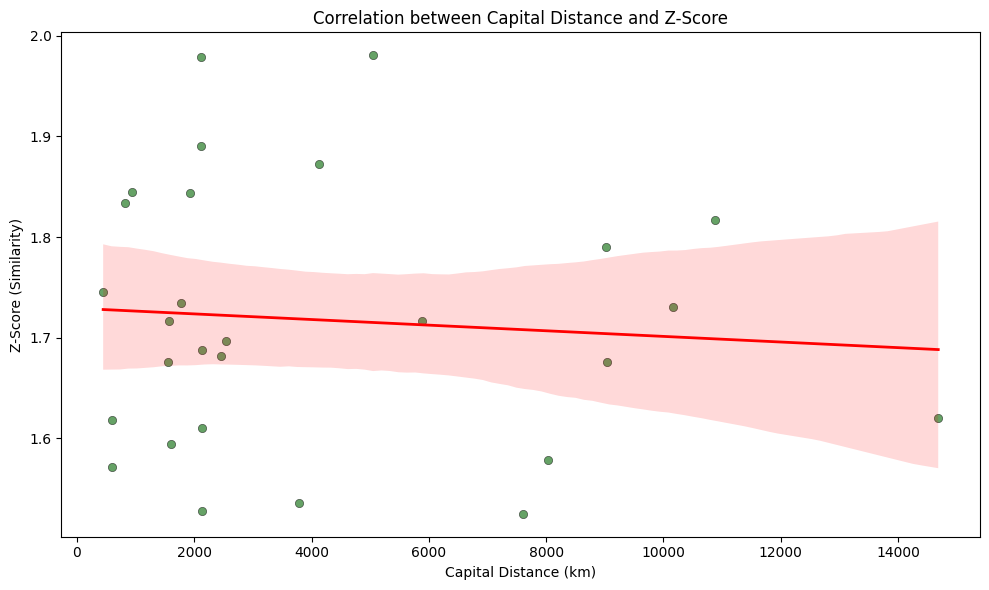

In [ ]:
# Compute Pearson correlation (with outlier removal)
replications_dist_corr = replications_with_dist.dropna(subset=['capital_distance_km', 'z_score'])

# Remove outliers using IQR for both distance and z_score
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)]

replications_dist_corr = remove_outliers_iqr(replications_dist_corr, 'capital_distance_km')
replications_dist_corr = remove_outliers_iqr(replications_dist_corr, 'z_score')

# Now compute Pearson correlation
dist_corr, dist_pval = pearsonr(replications_dist_corr['capital_distance_km'], replications_dist_corr['z_score'])
print(f"📏 Pearson Correlation Coefficient (Distance vs Z-Score): {dist_corr:.3f}")
print(f"📌 p-value: {dist_pval:.3e}")

# Scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=replications_dist_corr,
    x='capital_distance_km',
    y='z_score',
    alpha=0.6,
    color='darkgreen',
    edgecolor='black'
)
sns.regplot(
    data=replications_dist_corr,
    x='capital_distance_km',
    y='z_score',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2}
)
plt.title('Correlation between Capital Distance and Z-Score')
plt.xlabel('Capital Distance (km)')
plt.ylabel('Z-Score (Similarity)')
plt.tight_layout()
plt.show()


📊 Average Z-Score | Same Team Leads: 2.437
📊 Average Z-Score | Different Team Leads: 1.663
📌 T-Test p-value: 6.766e-07


<ipython-input-11-a5901d8ce4b5>:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([same_team, diff_team], labels=['Same Team Leads', 'Different Team Leads'], patch_artist=True)


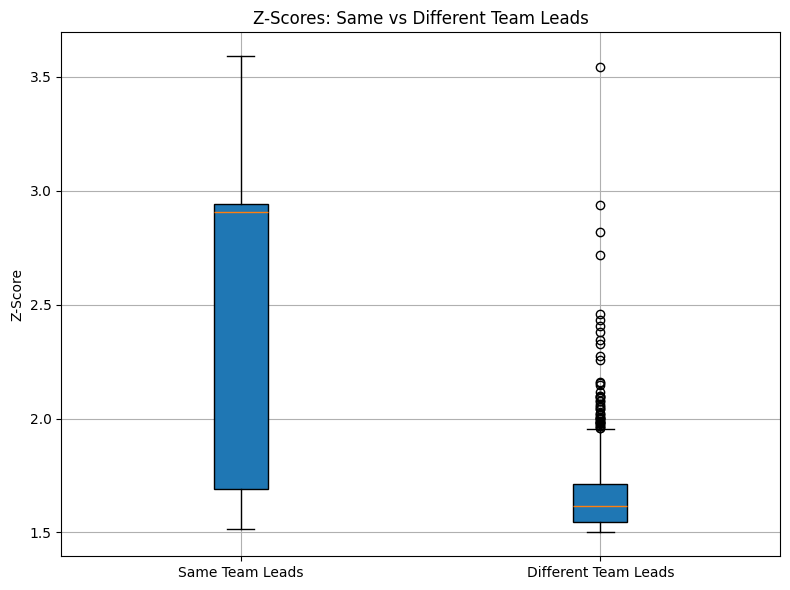

In [ ]:
import pandas as pd
import pickle
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt



# Load the replications CSV
replications = pd.read_csv("/content/csv2 - Sheet1.csv")

# Also load main_df from Excel
main_df = pd.read_excel("/content/wbg_Updated_7.xlsx")


# Normalize country names and drop duplicates
manual_aliases = {
    "islamic republic of pakistan": "Pakistan", "viet nam": "Vietnam", "lao pdr": "Laos",
    "russian federation": "Russia", "united republic of tanzania": "Tanzania", "republic of moldova": "Moldova",
    "state of palestine": None, "republic of north macedonia": "North Macedonia",
    "republic of cape verde": "Cabo Verde", "central african republic": "Central African Republic",
    "sierra leone": "Sierra Leone", "east asia and pacific": None, "south asia": None,
    "europe and central asia": None, "middle east and north africa region": None,
    "africa region": None, "yugoslavia": None, "hogwarts": None, "narnia": None, "south east europe": None
}

regions_to_exclude = [v for v in manual_aliases.values() if v is None]

def normalize_country(name):
    if pd.isna(name):
        return None
    name_cleaned = str(name).strip().lower().replace('\u00a0', ' ')
    return manual_aliases.get(name_cleaned, name.title())

main_df['Country'] = main_df['Country'].apply(normalize_country)
main_df_cleaned = main_df.drop_duplicates(subset='Project ID', keep='first')
project_id_to_country = main_df_cleaned.set_index('Project ID')['Country'].to_dict()
project_id_to_teamleads = main_df_cleaned.set_index('Project ID')['Team Leads'].to_dict()

# Clean replication DataFrame
replications = pd.DataFrame(replications)
replications['country_1'] = replications['document_id_1'].map(project_id_to_country)
replications['country_2'] = replications['document_id_2'].map(project_id_to_country)
replications = replications.dropna(subset=['country_1', 'country_2', 'z_score'])

# Filter out projects not in cleaned main_df
valid_ids = set(main_df_cleaned['Project ID'])
replications = replications[
    replications['document_id_1'].isin(valid_ids) &
    replications['document_id_2'].isin(valid_ids)
].copy()

# Get raw team leads
replications['teamleads_1_raw'] = replications['document_id_1'].map(project_id_to_teamleads)
replications['teamleads_2_raw'] = replications['document_id_2'].map(project_id_to_teamleads)

# Standardize team lead lists for comparison
def clean_teamleads(raw):
    if pd.isna(raw):
        return set()
    return set(t.strip().lower() for t in str(raw).split(';') if t.strip())

replications['teamleads_1'] = replications['teamleads_1_raw'].apply(clean_teamleads)
replications['teamleads_2'] = replications['teamleads_2_raw'].apply(clean_teamleads)

# Compare team leads
replications['same_teamleads'] = replications.apply(
    lambda row: row['teamleads_1'] == row['teamleads_2'], axis=1
)

# Split by same/different team leads
same_team = replications[replications['same_teamleads']]['z_score']
diff_team = replications[~replications['same_teamleads']]['z_score']

# Statistical test
t_stat, p_val = ttest_ind(same_team, diff_team, equal_var=False)

# Print stats
print("📊 Average Z-Score | Same Team Leads: {:.3f}".format(same_team.mean()))
print("📊 Average Z-Score | Different Team Leads: {:.3f}".format(diff_team.mean()))
print("📌 T-Test p-value: {:.3e}".format(p_val))

# --- Optional: Box Plot ---
plt.figure(figsize=(8, 6))
plt.boxplot([same_team, diff_team], labels=['Same Team Leads', 'Different Team Leads'], patch_artist=True)
plt.ylabel("Z-Score")
plt.title("Z-Scores: Same vs Different Team Leads")
plt.grid(True)
plt.tight_layout()
plt.show()
